In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare, norm

In [3]:
df = pd.read_excel('Anexo_9.3_GDLUNA.xlsx', skiprows=14)
df.columns = df.columns.str.replace('\n', ' ').str.strip()
print(df.columns)

Index(['Unnamed: 0', 'RFC', 'NOMBRE, DENOMINACIÓN Y/O RAZON SOCIAL',
       'DESCRIPCIÓN', 'FECHA DE ADQUISICIÓN (dd/mm/yyyy)',
       'MONTO PAGADO C/IVA (en pesos)',
       'ENTREGABLE (documento que acredite la entrega)',
       'MONTO PAGADO CON FORTAMUN',
       'PARTIDA ESPECÍFICA DEL CLASIFICADOR POR OBJETO DEL GASTO',
       'NÚM. FACTURA O FOLIO FISCAL', 'NÚM. PÓLIZA',
       'CVE. FUENTE DE   FINANCIAMIENTO'],
      dtype='str')


In [5]:
if 'MONTO PAGADO CON FORTAMUN' in df.columns:
    df['MONTO PAGADO CON FORTAMUN'] = (
        df['MONTO PAGADO CON FORTAMUN']
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df['MONTO PAGADO CON FORTAMUN'] = pd.to_numeric(df['MONTO PAGADO CON FORTAMUN'], errors='coerce')

if 'FECHA DE ADQUISICIÓN (dd/mm/yyyy)' in df.columns:
    df['FECHA DE ADQUISICIÓN'] = pd.to_datetime(
        df['FECHA DE ADQUISICIÓN (dd/mm/yyyy)'], 
        format='%d/%m/%Y', 
        errors='coerce'
    )



df = df.dropna(subset=['RFC','MONTO PAGADO CON FORTAMUN'])
print(df['MONTO PAGADO CON FORTAMUN'].head(10))

0      894.36
1      614.80
2     1600.80
3    13920.00
4    31384.96
5      812.00
6    42873.60
7     7200.00
8     6900.00
9    11250.00
Name: MONTO PAGADO CON FORTAMUN, dtype: float64


In [8]:
print("--- ESTADÍSTICAS GENERALES DE LOS MONTOS ---")
print(df['MONTO PAGADO CON FORTAMUN'].describe())

print("\n--- TOP 5 PROVEEDORES CON MAYOR MONTO TOTAL ACUMULADO ---")
top_proveedores = df.groupby('NOMBRE, DENOMINACIÓN Y/O RAZON SOCIAL')['MONTO PAGADO CON FORTAMUN'].sum()
print(top_proveedores.sort_values(ascending=False).head(5))

print("\n--- GASTO TOTAL POR PARTIDA ESPECÍFICA ---")
partida_gasto = df.groupby('PARTIDA ESPECÍFICA DEL CLASIFICADOR POR OBJETO DEL GASTO').agg(
    Total_Gastado=('MONTO PAGADO CON FORTAMUN', 'sum'),
    Numero_Transacciones=('MONTO PAGADO CON FORTAMUN', 'count')
)
print(partida_gasto)

print("\n--- TRANSACCIÓN MÁS ALTA REGISTRADA ---")
transaccion_max = df.loc[df['MONTO PAGADO CON FORTAMUN'].idxmax()]
print(f"Proveedor: {transaccion_max['NOMBRE, DENOMINACIÓN Y/O RAZON SOCIAL']}")
print(f"Monto: ${transaccion_max['MONTO PAGADO CON FORTAMUN']:.2f}")
print(f"Descripción: {transaccion_max['DESCRIPCIÓN']}")

--- ESTADÍSTICAS GENERALES DE LOS MONTOS ---
count       80.000000
mean      7981.301875
std       9741.844043
min          5.800000
25%       1505.100000
50%       4640.580000
75%      10925.750000
max      48720.000000
Name: MONTO PAGADO CON FORTAMUN, dtype: float64

--- TOP 5 PROVEEDORES CON MAYOR MONTO TOTAL ACUMULADO ---
NOMBRE, DENOMINACIÓN Y/O RAZON SOCIAL
EMMANUEL PULIDO CABRERA               75423.20
 FERNANDO DE JESUS MONCADA RAMIREZ    49226.92
 JAFET DAVID HERNANDEZ TORRES         42873.60
 ELIAZAR CALVILLO RODRIGUEZ           39876.00
 DANIEL ALBERTO GOMEZ FLORES          39228.67
Name: MONTO PAGADO CON FORTAMUN, dtype: float64

--- GASTO TOTAL POR PARTIDA ESPECÍFICA ---
                                                    Total_Gastado  \
PARTIDA ESPECÍFICA DEL CLASIFICADOR POR OBJETO ...                  
2000.0                                                  315215.86   
3000.0                                                  274568.29   
5000.0                         

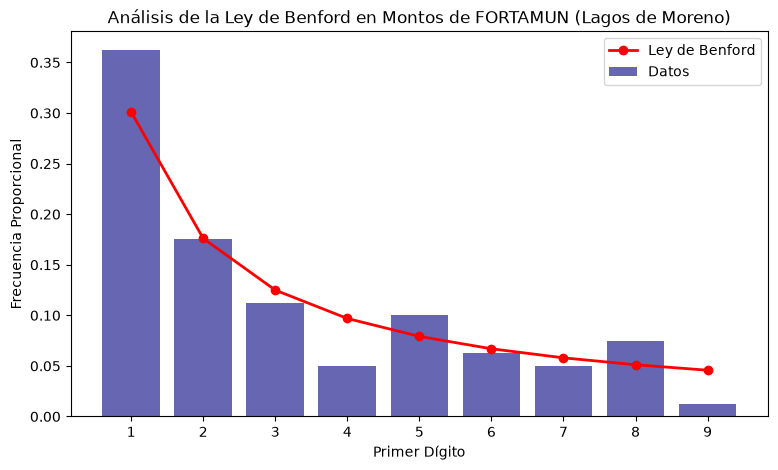

In [13]:
df_benford = df[df['MONTO PAGADO CON FORTAMUN'] > 0].dropna(subset=['MONTO PAGADO CON FORTAMUN'])
df_benford['PRIMER_DIGITO'] = df_benford['MONTO PAGADO CON FORTAMUN'].astype(str).str.lstrip('0. ').str[0]
df_benford = df_benford[df_benford['PRIMER_DIGITO'].str.isdigit() & (df_benford['PRIMER_DIGITO'] != '0')]
df_benford['PRIMER_DIGITO'] = df_benford['PRIMER_DIGITO'].astype(int)

# Frecuencias de los datos
conteos = df_benford['PRIMER_DIGITO'].value_counts(normalize=True).sort_index()

# Frecuencias teóricas de la Ley de Benford
digitos = np.arange(1, 10)
frecuencias_benford = np.log10(1 + 1 / digitos)


plt.figure(figsize=(9, 5))
plt.bar(conteos.index, conteos.values, alpha=0.6, color='navy', label='Datos')
plt.plot(digitos, frecuencias_benford, color='red', marker='o', linewidth=2, label='Ley de Benford')
plt.xlabel('Primer Dígito')
plt.ylabel('Frecuencia Proporcional')
plt.title('Análisis de la Ley de Benford en Montos de FORTAMUN (Lagos de Moreno)')
plt.xticks(digitos)
plt.legend()
plt.show()

In [14]:
conteos_absolutos = df_benford['PRIMER_DIGITO'].value_counts().sort_index()
total_datos = conteos_absolutos.sum()
conteos_absolutos = conteos_absolutos.reindex(range(1, 10), fill_value=0)

esperados_absolutos = frecuencias_benford * total_datos

# ==========================================
# PRUEBA CHI-CUADRADA
# ==========================================
chi2_stat, p_val_chi2 = chisquare(f_obs=conteos_absolutos, f_exp=esperados_absolutos)

print("=== ANÁLISIS GLOBAL ===")
print(f"Estadístico Chi2: {chi2_stat:.4f}")
print(f"p-valor global: {p_val_chi2:.4e}")
if p_val_chi2 < 0.05:
    print("Resultado: DESVIACIÓN SIGNIFICATIVA. Los datos NO siguen la Ley de Benford de forma natural.")
else:
    print("Resultado: NORMAL. Los datos se ajustan bien a la Ley de Benford.")
print("-" * 50)

# ==========================================
# PRUEBAS Z INDIVIDUALES
# ==========================================
print("=== ANÁLISIS DETALLADO DÍGITO POR DÍGITO ===")
resultados_z = []

for d in range(1, 10):
    obs = conteos_absolutos[d] / total_datos
    esp = frecuencias_benford[d-1]
    
    # Error estándar para la proporción
    se = np.sqrt((esp * (1 - esp)) / total_datos)
    
    # Cálculo del valor Z
    z_stat = (obs - esp) / se
    p_val_z = 2 * (1 - norm.cdf(abs(z_stat))) # Dos colas
    
    resultados_z.append({
        'Dígito': d,
        'Obs %': f"{obs*100:.1f}%",
        'Benford %': f"{esp*100:.1f}%",
        'Valor Z': f"{z_stat:+.2f}",
        'p-valor': f"{p_val_z:.4e}",
        '¿Es anomalía?': 'SÍ' if p_val_z < 0.05 else 'NO'
    })

df_reporte_z = pd.DataFrame(resultados_z)
print(df_reporte_z.to_string(index=False))

=== ANÁLISIS GLOBAL ===
Estadístico Chi2: 6.2932
p-valor global: 6.1443e-01
Resultado: NORMAL. Los datos se ajustan bien a la Ley de Benford.
--------------------------------------------------
=== ANÁLISIS DETALLADO DÍGITO POR DÍGITO ===
 Dígito Obs % Benford % Valor Z    p-valor ¿Es anomalía?
      1 36.2%     30.1%   +1.20 2.3068e-01            NO
      2 17.5%     17.6%   -0.03 9.7956e-01            NO
      3 11.2%     12.5%   -0.34 7.3651e-01            NO
      4  5.0%      9.7%   -1.42 1.5611e-01            NO
      5 10.0%      7.9%   +0.69 4.9044e-01            NO
      6  6.2%      6.7%   -0.16 8.7356e-01            NO
      7  5.0%      5.8%   -0.31 7.5973e-01            NO
      8  7.5%      5.1%   +0.97 3.3295e-01            NO
      9  1.2%      4.6%   -1.42 1.5458e-01            NO
